# Inhomogeneous Spatial Poisson Process — From Scratch and With NumPyro

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jejjohnson/xtremax/blob/main/docs/notebooks/ipp_spatial_from_scratch_and_numpyro.ipynb)

An **inhomogeneous spatial Poisson process** (IPP) on a domain $D \subset \mathbb{R}^d$ has a non-constant intensity $\lambda(s) \geq 0$. The total expected count is the integrated intensity

$$\Lambda(D) = \int_D \lambda(s)\, ds,$$

the count is $N \sim \mathrm{Poisson}(\Lambda)$, and the joint log-likelihood factorises as

$$\log L = \sum_{i=1}^n \log \lambda(s_i) - \Lambda(D).$$

Inhomogeneity is the bread and butter of applied spatial statistics: disease incidence around risk factors, earthquake epicentres along fault lines, methane plumes near industrial facilities, galaxies in the cosmic web. This notebook walks through the same two faces of `xtremax` as the homogeneous case.

1. **From scratch** — primitives for sampling (Lewis–Shedler thinning), evaluating the joint log-likelihood, and integrating the intensity over the box (trapezoid grid + Halton QMC).
2. **With NumPyro** — wrap the IPP as a `Distribution` and run NUTS to recover hyperparameters of a Gaussian-bump intensity field.

## Setup

In [1]:
%pip install -q xtremax matplotlib  # uncomment on Colab
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpyro
import numpyro.distributions as dist
from jax import random
from numpyro.infer import MCMC, NUTS

from xtremax.point_processes import (
    RectangularDomain,
    integrate_log_intensity_spatial,
)
from xtremax.point_processes.distributions import (
    InhomogeneousSpatialPP as IppSpatialDist,
)
from xtremax.point_processes.primitives import (
    ipp_spatial_intensity,
    ipp_spatial_log_prob,
    ipp_spatial_sample_thinning,
)


plt.rcParams["figure.figsize"] = (8.0, 4.0)

/home/azureuser/localfiles/xtremax/.venv/bin/python: No module named pip


Note: you may need to restart the kernel to use updated packages.


/home/azureuser/localfiles/xtremax/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. From scratch — the primitives layer

Start with a **single Gaussian bump** centred at the middle of a $[0, 10]^2$ domain. The log-intensity is a quadratic in space, so it has a tidy closed form for the integrated intensity (which we'll use to sanity-check the quadrature primitive).

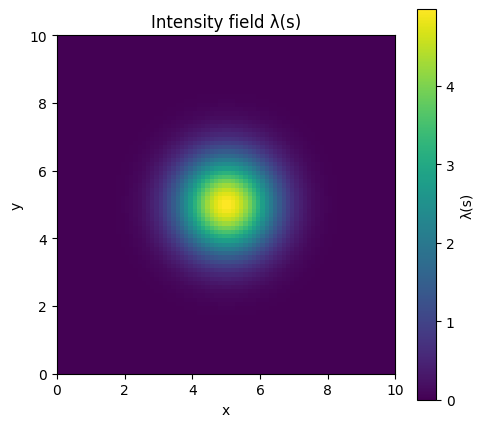

In [2]:
domain = RectangularDomain.from_size(jnp.array([10.0, 10.0]))


def log_intensity(s):
    # Smooth bump: λ(s) = 5 · exp(-0.5 ||s - 5||²). Peak intensity is 5.
    return jnp.log(5.0) - 0.5 * jnp.sum((s - 5.0) ** 2, axis=-1)


# Visualise the field on a grid.
xy = jnp.linspace(0, 10, 80)
X, Y = jnp.meshgrid(xy, xy)
grid = jnp.stack([X.ravel(), Y.ravel()], axis=-1)
intensity = jnp.exp(log_intensity(grid)).reshape(X.shape)

fig, ax = plt.subplots(figsize=(5, 4.5))
im = ax.imshow(intensity, extent=[0, 10, 0, 10], origin="lower", cmap="viridis")
plt.colorbar(im, label="λ(s)")
ax.set_xlabel("x"); ax.set_ylabel("y")
ax.set_title("Intensity field λ(s)")
plt.tight_layout()
plt.show()

### Integrated intensity

`integrate_log_intensity_spatial` computes $\Lambda(D)$ on the rectangular domain. Two methods: tensor-product trapezoid (best for $d \leq 2$ and smooth integrands) and Halton QMC (better for $d \geq 3$, robust to peaks). We compare against the analytical answer.

In [3]:
# Closed form: ∫∫ 5 · exp(-½ ((x-5)² + (y-5)²)) dx dy
#            = 5 · (∫_0^{10} exp(-½ (x-5)²) dx)²
#            = 5 · (√(2π) · (Φ(5) - Φ(-5)))²,  where Φ = standard normal CDF.
from jax.scipy.stats import norm

per_axis = jnp.sqrt(2.0 * jnp.pi) * (norm.cdf(5.0) - norm.cdf(-5.0))
exact = 5.0 * per_axis**2
trap = integrate_log_intensity_spatial(log_intensity, domain, n_points=4096, method="trapezoid")
qmc = integrate_log_intensity_spatial(log_intensity, domain, n_points=4096, method="qmc")
print(f"Analytical Λ(D)  = {float(exact):.4f}")
print(f"Trapezoid (4096) = {float(trap):.4f}")
print(f"QMC       (4096) = {float(qmc):.4f}")

Analytical Λ(D)  = 31.4159
Trapezoid (4096) = 31.4159
QMC       (4096) = 31.4339


### Sampling — Lewis–Shedler thinning

Sampling an IPP requires a thinning bound $\lambda_{\max} \geq \max_s \lambda(s)$ over the box. Procedure: draw an HPP at rate $\lambda_{\max}$ over $D$, then accept each candidate with probability $\lambda(s)/\lambda_{\max}$. Tighter bounds give higher acceptance.

Drew 467 candidates, 31 accepted (acceptance ≈ 6.64%)


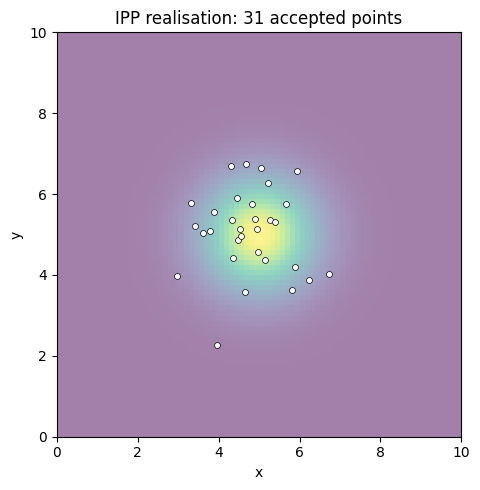

In [4]:
lambda_max = 5.0  # tight: peak intensity exactly 5.
locs, accepted, n_uncapped = ipp_spatial_sample_thinning(
    random.PRNGKey(0),
    log_intensity,
    domain,
    lambda_max=lambda_max,
    max_candidates=1024,
)
print(
    f"Drew {int(n_uncapped)} candidates, {int(accepted.sum())} accepted "
    f"(acceptance ≈ {float(accepted.sum() / n_uncapped):.2%})"
)

fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(intensity, extent=[0, 10, 0, 10], origin="lower", cmap="viridis", alpha=0.5)
real_locs = locs[accepted]
ax.scatter(real_locs[:, 0], real_locs[:, 1], s=18, color="white", edgecolors="black", linewidth=0.5)
ax.set_xlim(0, 10); ax.set_ylim(0, 10); ax.set_aspect("equal")
ax.set_title(f"IPP realisation: {int(accepted.sum())} accepted points")
ax.set_xlabel("x"); ax.set_ylabel("y")
plt.tight_layout()
plt.show()

### Joint log-likelihood

The decomposition $\log L = \sum \log \lambda(s_i) - \Lambda(D)$ is implemented directly. A useful diagnostic: drag the candidate parameters away from the truth and watch the log-likelihood drop.

In [5]:
log_p_truth = ipp_spatial_log_prob(locs, accepted, log_intensity, exact)
print(f"log L at truth = {float(log_p_truth):.2f}")

# A misspecified intensity (peak shifted to (8, 8)) should score lower.
def shifted_log_intensity(s):
    return jnp.log(5.0) - 0.5 * jnp.sum((s - 8.0) ** 2, axis=-1)


lambda_shifted = integrate_log_intensity_spatial(
    shifted_log_intensity, domain, n_points=4096, method="qmc"
)
log_p_shift = ipp_spatial_log_prob(locs, accepted, shifted_log_intensity, lambda_shifted)
print(f"log L at shifted peak = {float(log_p_shift):.2f}")

log L at truth = -10.37
log L at shifted peak = -303.70


## 2. With NumPyro — Bayesian inference for the intensity peak

Treat the centre and amplitude of the Gaussian bump as latent and recover them from the observed pattern. The wrapper class `InhomogeneousSpatialPP` integrates Λ(D) on every `log_prob` call so gradients flow into both the sum-of-log-intensities and the $-\Lambda$ term.

In [6]:
# Synthetic observation with a known peak.
true_centre = jnp.array([4.0, 6.0])
true_log_amp = jnp.log(5.0)


def true_log_intensity(s):
    return true_log_amp - 0.5 * jnp.sum((s - true_centre) ** 2, axis=-1)


obs_locs, obs_mask, _ = ipp_spatial_sample_thinning(
    random.PRNGKey(7),
    true_log_intensity,
    domain,
    lambda_max=5.0,
    max_candidates=1024,
)
print(f"Observed {int(obs_mask.sum())} points")

Observed 38 points


In [7]:
# Score the heterogeneous ``(locations, mask)`` PyTree via ``numpyro.factor``
# rather than ``numpyro.sample(..., obs=...)`` — see the HPP spatial
# notebook for the full rationale.
def model():
    centre = numpyro.sample("centre", dist.Normal(jnp.full(2, 5.0), 2.0))
    log_amp = numpyro.sample("log_amp", dist.Normal(0.0, 1.5))

    def log_lam(s):
        return log_amp - 0.5 * jnp.sum((s - centre) ** 2, axis=-1)

    spp = IppSpatialDist(
        log_lam,
        domain=domain,
        lambda_max=10.0,
        max_candidates=1024,
        n_integration_points=2048,
    )
    numpyro.factor("lik", spp.log_prob((obs_locs, obs_mask)))


mcmc = MCMC(
    NUTS(model),
    num_warmup=500,
    num_samples=1000,
    progress_bar=False,
)
mcmc.run(random.PRNGKey(0))
mcmc.print_summary()


                mean       std    median      5.0%     95.0%     n_eff     r_hat
 centre[0]      3.82      0.16      3.81      3.59      4.10   1157.76      1.00
 centre[1]      5.80      0.17      5.80      5.55      6.08    899.85      1.00
   log_amp      1.78      0.17      1.78      1.51      2.05    748.53      1.00

Number of divergences: 0


Posterior should concentrate around the true peak location $(4, 6)$ and amplitude $\log 5 \approx 1.61$.

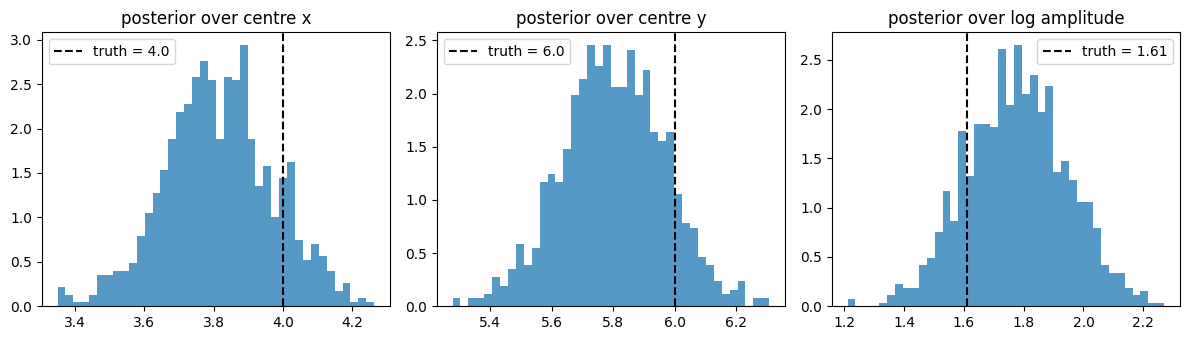

In [8]:
samples = mcmc.get_samples()
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))

for ax, key, truth in zip(
    axes[:2], ("centre x", "centre y"), (float(true_centre[0]), float(true_centre[1])), strict=False
):
    coord = 0 if "x" in key else 1
    ax.hist(samples["centre"][:, coord], bins=40, alpha=0.75, density=True)
    ax.axvline(truth, color="k", linestyle="--", label=f"truth = {truth}")
    ax.set_title(f"posterior over {key}")
    ax.legend()

axes[2].hist(samples["log_amp"], bins=40, alpha=0.75, density=True)
axes[2].axvline(float(true_log_amp), color="k", linestyle="--", label=f"truth = {float(true_log_amp):.2f}")
axes[2].set_title("posterior over log amplitude")
axes[2].legend()
plt.tight_layout()
plt.show()

## 3. Higher dimensions — same API

The whole pipeline scales to 3-D without code changes — only `domain_size` grows by one entry.

In [9]:
domain_3d = RectangularDomain.from_size(jnp.array([4.0, 4.0, 4.0]))


def log_intensity_3d(s):
    return jnp.log(2.0) - 0.5 * jnp.sum((s - 2.0) ** 2, axis=-1)


lam_d3 = integrate_log_intensity_spatial(
    log_intensity_3d, domain_3d, n_points=8192, method="qmc"
)
print(f"3-D Λ(D) ≈ {float(lam_d3):.3f}")

locs_3d, mask_3d, _ = ipp_spatial_sample_thinning(
    random.PRNGKey(0), log_intensity_3d, domain_3d, lambda_max=2.0, max_candidates=512
)
print(f"3-D realisation: {int(mask_3d.sum())} points in 4³ box")

3-D Λ(D) ≈ 27.393


3-D realisation: 23 points in 4³ box


## Where to go from here

- **Marked spatial patterns.** Pair each event with a magnitude — see the [Marked Spatial PP notebook](marked_spatial_from_scratch_and_numpyro.ipynb).
- **Tighter quadrature.** For sharply peaked intensities, increase `n_integration_points` or pass an analytical $\Lambda$ via the operator's `integrated_intensity=` argument.
- **Neural intensities.** Replace the analytical bump with an `eqx.Module` (e.g. a small MLP). Its parameters become PyTree leaves and gradients flow through `log_prob`.